---
title: Figures
---

On this page you can find all figures and code to produce the figures of the manuscript. 

In [21]:
#| echo: false
#| output: false
%config InlineBackend.figure_format = 'svg'
%config InlineBackend.print_figure_kwargs = {'bbox_inches': 'tight'}
%config InlineBackend.print_figure_kwargs = {'pad_inches': 0}
check_size = False

## Introduction

### Figure 1

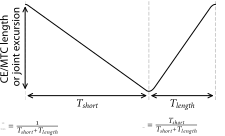

In [22]:
#| label: fig-i-ssc-parameterisation
#| fig-cap: Parameterisation of stretch-shortening cycles. $T_{short}$ and $T_{length}$ denote the shortening and lengthening 
#|   durations. FTS denotes the fraction of the cycle time spent shortening. In the example shown, the shortening duration is 65% 
#|   of the cycle duration (i.e. FTS = 0.65).

#%% Imports etc.
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
cwd = Path.cwd()
baseDir = cwd.parent
dataDir = baseDir / 'data'
funcDir = baseDir / 'analysis' / 'functions'
sys.path.append(str(funcDir))

# Custom imports
import cust_fig, trajectories

plt.close('all')

#%% Generate lmtc(t)
cf = 1
fts = 0.65
amp = 1 # [m]
lmtcAvg = 0
acc = 200

time = np.linspace(0,1/cf,1000)
lmtc = trajectories.dino(time,cf,fts,amp*2,lmtcAvg,acc)[0]

# %% Figure setup
cust_fig.style(plt, fontname='Minion Pro', fontsize=11, grid=True)

# plt.rcParams['svg.fonttype'] = 'path'  # key setting
    
fig = plt.figure(figsize=(7.96/2.54+3/600, 4.8/2.54), constrained_layout=True) # 3:2 ratio (1889.763779528 x 1259.8425196853334) px @ 600dpi
fig.set_constrained_layout_pads(w_pad=0, h_pad=0, hspace=0, wspace=0)
gs = fig.add_gridspec(1,1)
axs = np.array([[fig.add_subplot(gs[i, j]) for j in range(gs.ncols)] for i in range(gs.nrows)])

ax = axs[0,0]
ax.plot(time,lmtc,'k')

# Length excursion
ax.annotate("", xy=(0, -1), xytext=(0, 1),
            arrowprops=dict(arrowstyle="<->"))
text = ax.text(-0.075,0, "CE/MTC length \n or joint excursion", color='k',ha='center', va='center', rotation = 90)

# Tshort
ax.annotate("", xy=(fts/cf, -1.1), xytext=(0, -1.1),
            arrowprops=dict(arrowstyle="<->"))
ax.text(fts/cf/2,-1.35, '$T_{short}$', color='k',ha='center')

# Tlength
ax.annotate("", xy=(1, -1.1), xytext=(fts/cf, -1.1),
            arrowprops=dict(arrowstyle="<->"))
ax.text(fts/cf+(1-fts)/cf/2,-1.35, "$T_{length}$", color='k',ha='center')

# CF & FTS
ax.text(
    -0.128, -1.8,
    r"$\substack{\text{\normalsize Cycle} \\ \text{\normalsize frequency}} = \frac{1}{T_{short} + T_{length}}$",
    color='k',
    ha='left',
    va='center',
    usetex=True
)
ax.text(
    1/cf,-1.8,
    r"$\text{\normalsize FTS} = \frac{T_{short}}{T_{short} + T_{length}}$",
    color='k',
    ha='right',
    va='center',
    usetex=True
)

# %% 
ax.set_xlim(0,1/cf+0.05)
ax.set_ylim(-1.2,1.1)
ax.set_xticks([0,fts/cf,1/cf])
ax.set_xticklabels(['','','']) 
ax.set_yticks([])
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# %% Save and display
plt.show()   
#fig.savefig('i_ssc_parameterisation.png', bbox_inches="tight", pad_inches=0, dpi=600)
fig.savefig('i_ssc_parameterisation.pdf', bbox_inches="tight", pad_inches=0)
#fig.savefig('i_ssc_parameterisation.svg', bbox_inches="tight", pad_inches=0)

# %% Checks
if len(sys.argv) > 1:
    check_size = sys.argv[1]
else:
    check_size = True  

if check_size == True or check_size == 'True':
    cust_fig.report_axes_size(fig,axs.flatten())
    #cust_fig.report_fig_size("i_ssc_parameterisation.png") 
    cust_fig.report_fig_size("i_ssc_parameterisation.pdf") 
    #cust_fig.report_fig_size("i_ssc_parameterisation.svg") 


## Methods

### Figure 2

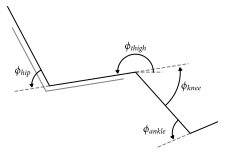

In [34]:
#| label: fig-m-setup
#| fig-cap: The experimental setup.

#%% Imports etc.
import sys
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Paths
cwd = Path.cwd()
baseDir = cwd.parent
dataDir = baseDir / 'data'
funcDir = baseDir / 'analysis' / 'functions'
sys.path.append(str(funcDir))

# Custom imports
import cust_fig

plt.close('all')

#%%
L = np.array([0.165,0.458,0.485,0.5])

phi_thigh = 3.3 # [rad]
phi_hip = 1.9 # [rad]
phi_knee = 1 # [rad]
phi_ankle = 1.9 # [rad]
phi_ll = (3.3-np.pi)-phi_knee # [rad]
phi_foot = phi_ll+np.pi-phi_ankle # [rad]
phi_trunk = phi_hip+(phi_thigh-np.pi) # [rad]

knee = np.array([[0,0]])
ankle = knee+L[1]*np.array([[np.cos(phi_ll),np.sin(phi_ll)]])
toe = ankle+L[0]*np.array([[np.cos(phi_foot),np.sin(phi_foot)]])
hip = knee+L[2]*np.array([[np.cos(phi_thigh),np.sin(phi_thigh)]])
shoulder = hip + L[3]*np.array([[np.cos(phi_trunk),np.sin(phi_trunk)]])
chair = np.concatenate((0.1*hip,hip,0.8*(shoulder-hip)+hip),axis=0)
chair = chair - np.array([[.02,.03]])
model = np.concatenate((toe,ankle,knee,hip,shoulder),axis=0)

l_foot = ankle+0.2*np.array([[0, 0],[np.cos(phi_foot-np.pi),np.sin(phi_foot-np.pi)]])
l_thigh = knee+0.3*np.array([[0, 0],[np.cos(phi_thigh+np.pi),np.sin(phi_thigh+np.pi)]])
l_hor = knee+0.15*np.array([[0,0], [1,0]])
l_thigh2 = hip-0.2*np.array([[0, 0],[np.cos(phi_thigh+np.pi),np.sin(phi_thigh+np.pi)]])

# %% Figure setup
cust_fig.style(plt, fontname='MinionPro', fontsize=11, grid=False)

space = 0; 
fig = plt.figure(figsize=(7.92/2.54+60/600, 2.23), constrained_layout=True)
gs = fig.add_gridspec(1, 1)
axs = np.array([[fig.add_subplot(gs[i, j]) for j in range(gs.ncols)] for i in range(gs.nrows)])

# %% Plot
ax = axs[0,0]
ax.plot(model[:,0],model[:,1],color='k')
ax.axis('equal')
ax.plot(chair[:,0],chair[:,1],color='gray',zorder=0)

ax.plot(l_foot[:,0],l_foot[:,1],linestyle='--',color='k',alpha=0.5) # for line foot
ax.plot(l_thigh[:,0],l_thigh[:,1],linestyle='--',color='k',alpha=0.5)
ax.plot(l_hor[:,0],l_hor[:,1],linestyle='--',color='k',alpha=0.5)
ax.plot(l_thigh2[:,0],l_thigh2[:,1],linestyle='--',color='k',alpha=0.5)

# phi thigh
cust_fig.draw_circle(ax,0.2,knee[0,0],knee[0,1],0,phi_thigh, shrink=0.2) 
ax.text(knee[0,0],knee[0,1]+0.14,'$\phi_{thigh}$',va='center',ha='center')

# phi knee
cust_fig.draw_circle(ax,0.5,knee[0,0],knee[0,1],phi_ll,phi_knee, shrink=0.1) 
ax.text(knee[0,0]+0.31,knee[0,1]-0.08,'$\phi_{knee}$',va='center',ha='center')

# phi hip
cust_fig.draw_circle(ax,0.2,hip[0,0],hip[0,1],phi_trunk,np.pi-phi_hip,shrink=0.2) 
ax.text(hip[0,0]-0.15,hip[0,1]+0.08,'$\phi_{hip}$',va='center',ha='center')

# phi ankle
cust_fig.draw_circle(ax,0.2,ankle[0,0],ankle[0,1],np.pi+phi_ll,np.pi-phi_ankle,shrink=0.2) 
ax.text(ankle[0,0]-0.20,ankle[0,1]+0.02,'$\phi_{ankle}$',va='center',ha='center')

# %% Labels etc. 
ax.axison = False
mn = np.amin(model,axis=0)
mx = np.amax(model,axis=0)
ax.set_aspect('equal', adjustable='datalim')
# ax.set_xlim([np.amin(chair),mx[0]])

# ax.set_xlim([mn[0],mx[0]])
# ax.set_xbound(lower=mn[0], upper=mx[0])

# ax.set_ylim([mn[1],mx[1]])
# ax.set_ylim([l_foot[1,1],mx[1]])

# %% Show and save 
plt.show()
#fig.savefig('m_setup.png', bbox_inches='tight', pad_inches=space, dpi=600)
fig.savefig('m_setup.pdf', bbox_inches='tight', pad_inches=space)
#fig.savefig('m_setup.svg', bbox_inches='tight', pad_inches=space)

# %% Checks
if len(sys.argv) > 1:
    check_size = sys.argv[1]
else:
    check_size = True  

if check_size == True or check_size == 'True':
    cust_fig.report_axes_size(fig,axs.flatten())
    # cust_fig.report_fig_size("m_setup.png") 
    cust_fig.report_fig_size("m_setup.pdf") 
    # cust_fig.report_fig_size("m_setup.svg")

### Figure 3

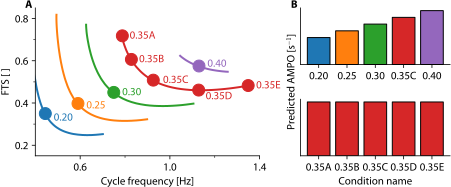

In [ ]:
#| label: fig-m-conditions
#| fig-cap: |
#|   Predicted maximally attainable AMPO and experimental conditions. A) Contour lines depict model-based predictions of 
#|   maximally attainable AMPO as a function of cycle frequency and FTS for a knee joint excursion of 1.6 rad. Contour lines 
#|   are only shown for experimentally feasible conditions (due to limits set on knee joint acceleration; see Appendix). 
#|   Dots indicate the nine conditions selected to be evaluated experimentally. B) Barplots of the same conditions: top, subset 
#|   predicted to differ in maximally attainable normalised AMPO (i.e. 0.20, 0.25, 0.30, 0.35C and 0.40); bottom, subset predicted 
#|   to yield identical maximally attainable normalised AMPO (0.35A-E).

#%% Imports etc.
import os, sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
cwd = Path.cwd()
baseDir = cwd.parent
dataDir = baseDir / 'data'
funcDir = baseDir / 'analysis' / 'functions'
sys.path.append(str(funcDir))

# Custom imports
import cust_fig, stats

plt.close('all')

#%% Data
parFile = os.path.join(dataDir,'VAS_muspar.pkl')
muspar = pickle.load(open(parFile, 'rb'))

parFile = os.path.join(dataDir,'VAS_muspar.pkl')
muspar = pickle.load(open(parFile, 'rb'))

acc = 50 # [rad/s^2]
kje = 1.6 # [rad]
maxcf = (0.5)*acc**(1/2)/2/kje**(1/2) # maximum CF that can be imposed given acc and amp

cf_set = np.arange(np.floor(maxcf*100)/100,0.33,-0.02)[::-1] # range of CF that we can investigate
fts_max = 1 - (2*cf_set*kje**(1/2))/acc**(1/2) # maximum fts that can be imposed given acc, amp and cf
fts_wide_range = np.hstack([1-stats.floor(fts_max,3), stats.floor(fts_max[::-1],3)]) # maximum range of cf

ampo = np.full((len(fts_wide_range),len(cf_set)),np.nan)
for iCf,cf in enumerate(cf_set): # [Hz]
    fts_set = fts_wide_range[iCf:-iCf]
    for iFts,fts in enumerate(fts_set):  
        filepath = os.path.join(dataDir,'simsExp',f'kje{kje:0.2f}rad_cf{cf:0.2f}Hz_fts{fts:0.3f}.csv')
        try:
            df = pd.read_csv(filepath)
            data = df.T.to_numpy()
            time,phi,stim,fsee,gamma,lcerel,q,lmtc,fisomrel = data
        
            ampo[iFts+iCf,iCf] = -np.trapezoid(fsee*muspar['A1'],phi)*cf/(muspar['fmax']*muspar['lce_opt'])
        except:
            None
X, Y = np.meshgrid(cf_set,fts_wide_range)

# %% Figure setup
cust_fig.style(plt, fontname='MinionPro', fontsize=11, grid=False)

fig = plt.figure(figsize=(15.92/2.54+50/600, 6.84/2.54), constrained_layout=True) 
gs = fig.add_gridspec(2, 2, height_ratios = [1,1], width_ratios=[1.5,1])
axs = np.array([[fig.add_subplot(gs[i, j]) for j in range(gs.ncols)] for i in range(gs.nrows)])
axs[0,0].remove(); axs[1,0].remove(); 
axs[0,0] = fig.add_subplot(gs[:, 0])

colorSet = plt.rcParams['axes.prop_cycle'].by_key()['color']

# %% Conditions
c_cf = np.array([0.4446,0.5902,0.7498,0.9260,1.1298, 0.7880,0.8284,1.1284,1.3491])
c_fts = np.array([0.3500,0.3978,0.4503,0.5082,0.5751, 0.7181,0.6064,0.4612,0.4827])
c_ampo = np.array([0.2,0.25,0.3,0.35,0.4,0.35,0.35,0.35,0.35])
c_clrs = [colorSet[0],colorSet[1],colorSet[2],colorSet[3],colorSet[4],colorSet[3],colorSet[3],colorSet[3],colorSet[3]]
c_num = ('1','2','3','4','5','6','7','8','9')

# %% Panel A: Contour plot
ax = axs[0,0]
ax.contour(X,Y,ampo,[0.2,0.25,0.30,0.35,0.40],colors=colorSet,linewidths=2)
ax.set_xlabel('Cycle frequency [Hz]')
ax.set_ylabel('FTS [ ]')
ax.set_xlim(0.4,1.4)
ax.set_ylim(0.15,0.85)
ax.set_xticks([0.6,1.0,1.4])
ax.set_xticks([0.8,1.2], minor=True)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticks([0.3, 0.5, 0.7], minor=True)

for iCond,(cf,fts,clr) in enumerate(zip(c_cf,c_fts,c_clrs)):
    ax.plot(cf,fts,marker='o',markersize=12,markerfacecolor=clr,markeredgecolor=clr)

ft_size = 'medium'
ax.text(c_cf[0]+0.08,c_fts[0]-0.02,"0.20",ha="center",va="center",color=c_clrs[0],fontsize=ft_size)
ax.text(c_cf[1]+0.08,c_fts[1]-0.01,"0.25",ha="center",va="center",color=c_clrs[1],fontsize=ft_size)
ax.text(c_cf[2]+0.08,c_fts[2]-0.00,"0.30",ha="center",va="center",color=c_clrs[2],fontsize=ft_size)
ax.text(c_cf[3]+0.10,c_fts[3]-0.00,"0.35C",ha="center",va="center",color=c_clrs[3],fontsize=ft_size)
ax.text(c_cf[4]+0.08,c_fts[4]+0.01,"0.40",ha="center",va="center",color=c_clrs[4],fontsize=ft_size)
ax.text(c_cf[5]+0.09,c_fts[5]-0.00,"0.35A",ha="center",va="center",color=c_clrs[5],fontsize=ft_size)
ax.text(c_cf[6]+0.09,c_fts[6]-0.00,"0.35B",ha="center",va="center",color=c_clrs[6],fontsize=ft_size)
ax.text(c_cf[7]+0.09,c_fts[7]-0.03,"0.35D",ha="center",va="center",color=c_clrs[7],fontsize=ft_size)
ax.text(c_cf[8]+0.09,c_fts[8]-0.00,"0.35E",ha="center",va="center",color=c_clrs[8],fontsize=ft_size)

# %% Panel B1: Barplot different AMPO
ax = axs[0,1]

x = [0,1,2,3,4]
y = [0.20, 0.25, 0.30, 0.35, 0.40]
ax.bar(x,y, color=colorSet, edgecolor="k", capsize=4)
ax.set_yticks([])
ax.set_xticks(x)
ax.set_xticklabels(["0.20","0.25","0.30","0.35C","0.40"])

# %% Panel B2: Barplot identical AMPO
ax = axs[1,1]

x = [0,1,2,3,4]
y = [0.4,0.4,0.4,0.4,0.4]
ax.bar(x,y, color=colorSet[3], edgecolor="k", capsize=4)
ax.set_yticks([])
ax.set_xticks(x)
ax.set_xticklabels(["0.35A","0.35B","0.35C","0.35D","0.35E"])

ax.set_xlabel(r'Condition name',usetex=False)

# %% Labels etc. 
ax_fake = fig.add_subplot(gs[:, 1])  # middle column spans both rows
ax_fake.set_frame_on(False)
ax_fake.set_xticks([])             # hide x ticks
ax_fake.set_yticks([])             # hide y ticks
ax_fake.patch.set_visible(False)   # hide background
for spine in ax_fake.spines.values():  # hide spines
    spine.set_visible(False)
ax_fake.set_ylabel('Predicted AMPO ' + r'[$\mathregular{s}^{-1}$]',usetex=False)  # x can be tweaked slightly

cust_fig.add_labels(fig, axs.flatten(), ['A', 'B'])

fig.align_labels()

# %% Show and save 
plt.show()
# fig.savefig('m_conditions.png', bbox_inches="tight", pad_inches=0, dpi=600)
fig.savefig('m_conditions.pdf', bbox_inches="tight", pad_inches=0)
# fig.savefig('m_conditions.svg', bbox_inches="tight", pad_inches=0)

# %% Checks
if len(sys.argv) > 1:
    check_size = sys.argv[1]
else:
    check_size = True  

if check_size == True or check_size == 'True':
    cust_fig.report_axes_size(fig,axs.flatten())
    # cust_fig.report_fig_size("m_conditions.png") 
    cust_fig.report_fig_size("m_conditions.pdf") 
    # cust_fig.report_fig_size("m_conditions.svg") 

## Results

### Figure 4

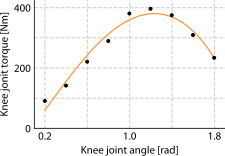

In [25]:
#| label: fig-r-te-isometric
#| fig-cap: |
#|   Representative example of maximal isometric knee joint moment as a function of knee joint angle, shown for 
#|   participant 5. Maximal knee joint moment was measured (black dots) and used to estimate $L_{SEE}^0$, 
#|   $L_{CE}^{opt}$ and $F_{CE}^{max}$. The resulting maximal isometric knee joint moment of the musculoskeletal 
#|   model is depicted by the orange line.

#%% Imports etc.
import os, sys, pickle, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import io
from pathlib import Path

# Paths
cwd = Path.cwd()
baseDir = cwd.parent
dataDir = baseDir / 'data'
funcDir = baseDir / 'analysis' / 'functions'
sys.path.append(str(funcDir))

# Custom imports
import cust_fig, hillmodel, signal_processing

plt.close('all')

# %% Load parameters
parFile = os.path.join(dataDir,'VAS_muspar.pkl')
muspar = pickle.load(open(parFile, 'rb'))

#%% Step 0: Load data
PPs = [5]
nPP = len(PPs)

phi_set = np.full((nPP,11), np.nan)
tor_set = np.full((nPP,11), np.nan)
for iPP, PP in enumerate(PPs):
    # Build folder path
    folder_path = os.path.join(dataDir, 'dataExp', f'pp{PP:02d}', 'day3')
    # File pattern: starts with 'pp01_day3_mh' and ends with '.mat'
    file_pattern = os.path.join(folder_path, f'pp{PP:02d}_day3_mh*.mat')
    # Find all matching files
    mat_files = sorted(glob.glob(file_pattern))
    
    for iFile,filepath in enumerate(mat_files):
        mat = io.loadmat(filepath)
        cfg = mat["Cfg"]
        data = mat["Data"]
        
        # Extract metadata
        fs = cfg["SampleFrequency"][0][0][0][0]
        
        # Extract dynamometer data
        phi = data[:, 0] / 180 * np.pi  # [rad] knee angle
        tor = data[:, 1] # [Nm] net knee joint torque
        time = np.arange(len(phi)) / fs  #  [s]
        
        # Compute moving average of 500 ms
        phi_movmean = signal_processing.moving_average(phi, dt=0.5, fs=fs)
        tor_movmean = signal_processing.moving_average(tor, dt=0.5, fs=fs)
        iMax = np.argmax(tor_movmean)
        phi_set[iPP,iFile] = phi_movmean[iMax]
        tor_set[iPP,iFile] = tor_movmean[iMax]

#%% Trow away lowest of repeated conditons
valid_mask = np.ones_like(tor_set, dtype=bool)  # start with all True

for iPP, pp in enumerate(PPs):
    # Build folder path
    folder_path = os.path.join(dataDir, 'dataExp', f'pp{pp:02d}', 'day3')
    # File pattern: starts with 'pp01_day3_mh' and ends with '.mat'
    file_pattern = os.path.join(folder_path, f'pp{pp:02d}_day3_mh*.mat')
    # Find all matching files
    mat_files = sorted(glob.glob(file_pattern))
    
    # Extract condition and trial type (t1 or t2)
    trials = [os.path.basename(f).split('_')[3].split('.')[0] for f in mat_files]  # t1, t2
    
    iPosts = [i for i, t in enumerate(trials) if t == 't2']
    iPres = [i-1 for i in iPosts]
    
    if not np.allclose(phi_set[iPP,iPres],phi_set[iPP,iPosts],rtol=0.001):
        # We have a problem, probably not the same knee angle!
        breakpoint()
    
        
    # Mask the trial with lower torque
    for iPre, iPost in zip(iPres, iPosts):
        if tor_set[iPP, iPre] < tor_set[iPP, iPost]:
            valid_mask[iPP, iPre] = False
        else:
            valid_mask[iPP, iPost] = False

phi_exp = phi_set[valid_mask].reshape(nPP, -1)
tor_exp = tor_set[valid_mask].reshape(nPP, -1)

#%% Load muscle parameter values
filepath = os.path.join(dataDir,'isometric-measurements.csv')
df = pd.read_csv(filepath, index_col=0)

fmax = df['fmax [N]'][pp] # [N]
lce_opt = df['lce_opt [cm]'][pp]/100 #[m]
lsee0 = df['lsee0 [cm]'][pp]/100 # [m]

#%% Compute model tor
parms = muspar.copy()
parms['fmax']       = fmax
parms['lce_opt']    = lce_opt
parms['lsee0']      = lsee0

phi_mdl = np.linspace(phi_exp.min(),phi_exp.max(),100)
lmtc    = phi_mdl*parms['A1']+parms['A0']
fsee    = hillmodel.force_eq(lmtc,1,parms)[0]
tor_mdl = fsee*parms['A1']

# %% Figure setup
cust_fig.style(plt, fontname='MinionPro', fontsize=11, grid=True)

fig = plt.figure(figsize=(15.92/2/2.54 + 50/600, 5.72/2.54), constrained_layout=True)
gs = fig.add_gridspec(1, 1)
axs = np.array([[fig.add_subplot(gs[i, j]) for j in range(gs.ncols)] for i in range(gs.nrows)])

# %% Plot
ax = axs[0,0]
ax.plot(phi_mdl,tor_mdl, color="C1")
ax.plot(phi_exp,tor_exp, marker=".", color="k", linewidth=0)
ax.set_xlabel("Knee joint angle [rad]")
ax.set_ylabel("Knee jonit torque [Nm]")
ax.set_xlim(0.1,1.9)
ax.set_xticks([0.2,0.6,1.0,1.4,1.8])
ax.set_xticks([0.4,0.8,1.2,1.6],minor=True)
ax.set_ylim(0,425)
ax.set_yticks([0,100,200,300,400])
ax.set_yticks([50,150,250,350],minor=True)

# %%
ax.set_xticks([0.2, 1.0, 1.8])
ax.set_xticks([0.6, 1.4],minor=True)
ax.set_ylim(0,425)
ax.set_yticks([0, 200, 400])
ax.set_yticks([100, 300],minor=True)

# %% Show and save
plt.show()
# fig.savefig("r_te_isometric.png", bbox_inches="tight", pad_inches=0, dpi=600)
fig.savefig("r_te_isometric.pdf", bbox_inches="tight", pad_inches=0)
# fig.savefig("r_te_isometric.svg", bbox_inches="tight", pad_inches=0)

# %% Checks
if len(sys.argv) > 1:
    check_size = sys.argv[1]
else:
    check_size = True  

if check_size == True or check_size == 'True':
    cust_fig.report_axes_size(fig,axs.flatten())
    # cust_fig.report_fig_size("r_te_isometric.png") 
    cust_fig.report_fig_size("r_te_isometric.pdf") 
    # cust_fig.report_fig_size("r_te_isometric.svg") 


### Figure 5

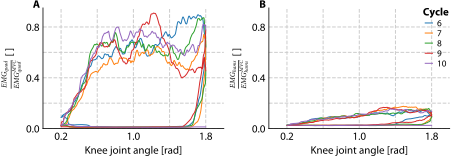

In [26]:
#| label: fig-r-te-emg
#| fig-cap: |
#|   Representative example of measured EMG, shown for participant 5 under condition 0.35C. A) EMG of 
#|   *m. vastus medialis* normalised by its $EMG^{MVC}$ value as a function of knee joint angle. EMG values 
#|   increased just before the transition from flexion to extension and were close to zero during flexion, 
#|   indicating that the timing of *m. quadriceps femoris* activation of participants was adequate. B) EMG 
#|   of the *m. biceps femoris* normalised by its $EMG^{MVC}$ value as a function of knee joint angle. EMG 
#|   values increased just before the transition from flexion to extension, following a similar time course 
#|   as the EMG values of *m. vastus medialis*, suggesting possible co-contraction. During flexion, EMG values 
#|   were close to zero, indicating participants adequately relaxed their the hamstring muscle group during flexion.

#%% Imports etc.
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
cwd = Path.cwd()
baseDir = cwd.parent
dataDir = baseDir / 'data'
funcDir = baseDir / 'analysis' / 'functions'
sys.path.append(str(funcDir))

# Custom imports
import cust_fig, helpers

plt.close('all')

# %% Load data
pp = 5
day = 4
cond = '0.35C'
trial = 1

dataFldr = os.path.join(dataDir,'dataExp',f'pp{pp:02d}','AMPO measurements','')
filename = f'pp{pp:02d}_{cond}_t{trial:1d}'
df = pd.read_csv(dataFldr+filename+'.csv')
data = df.to_numpy()
time,phi,_,torqueComp,_,_,emgQuad,emgHams,phase = data.T[0:9]

mTime = helpers.segments_to_array(time,phase)
mPhi = helpers.segments_to_array(phi,phase)
mEMGquad = helpers.segments_to_array(emgQuad,phase)
mEMGhams = helpers.segments_to_array(emgHams,phase)

# %% Figure setup
cust_fig.style(plt, fontname='MinionPro', fontsize=11, grid=True)

fig = plt.figure(figsize=(15.92/2.54+50/600, 5.75/2.54), constrained_layout=True)
gs = fig.add_gridspec(1, 2)
axs = np.array([[fig.add_subplot(gs[i, j]) for j in range(gs.ncols)] for i in range(gs.nrows)])

# %% Panel A: quadriceps EMG
ax = axs[0,0]
ax.plot(mPhi[:,5:10],mEMGquad[:,5:10])
ax.set_xlabel("Knee joint angle [rad]")
ax.set_ylabel(r'$\frac{EMG_{quad}}{EMG_{quad}^{MVC}}$ [ ]')
ax.set_xlim(0,2)
ax.set_ylim(0,0.95)
ax.set_xticks([0.2, 1.0, 1.8])
ax.set_xticks([0.6, 1.4],minor=True)
ax.set_yticks([0,0.4,0.8])
ax.set_yticks([0.2,0.6], minor=True)

# %% Panel B: hamstring EMG
ax = axs[0,1]
ax.plot(mPhi[:,5:10],mEMGhams[:,5:10])
ax.set_xlim(0,2)
ax.set_ylim(0,0.95)
ax.set_xlabel("Knee joint angle [rad]")
ax.set_ylabel(r'$\frac{EMG_{hams}}{EMG_{hams}^{MVC}}$ [ ]')
ax.set_xticks([0.2, 1.0, 1.8])
ax.set_xticks([0.6, 1.4],minor=True)
ax.set_yticks([0,0.4,0.8])
ax.set_yticks([0.2,0.6], minor=True)

# %%
axs[0,1].legend(
    ["6","7","8","9","10"],
    title='Cycle',
    title_fontproperties={'weight': 'bold'},
    loc="upper right", 
    bbox_to_anchor=(1.02, 1.04),
    handlelength=0.8,
    handletextpad=0.5,
    labelspacing=0.2
)

cust_fig.add_labels(fig, axs.flatten(), ['A', 'B'])

# %% Show and save
plt.show()
# fig.savefig("r_te_emg.png", bbox_inches="tight", pad_inches=0, dpi=600)
fig.savefig("r_te_emg.pdf", bbox_inches="tight", pad_inches=0)
# fig.savefig("r_te_emg.svg", bbox_inches="tight", pad_inches=0)

# %% Checks
if len(sys.argv) > 1:
    check_size = sys.argv[1]
else:
    check_size = True  

if check_size == True or check_size == 'True':
    cust_fig.report_axes_size(fig,axs.flatten())
    # cust_fig.report_fig_size("r_te_emg.png") 
    cust_fig.report_fig_size("r_te_emg.pdf") 
    # cust_fig.report_fig_size("r_te_emg.svg") 


### Figure 6

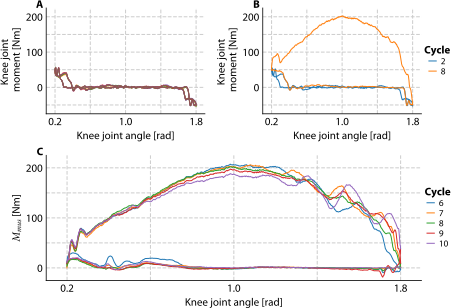

In [27]:
#| label: fig-r-te-kinetics
#| fig-cap: |
#|   Representative example of mechanical behaviour, shown for participant 5 under condition 0.35C. A) Knee 
#|   joint moment during passive cycles. Every individual cycle is represented by a different coloured line. 
#|   B) Knee joint moment during (passive) cycle 2 (blue line) and during (active) cycle 8 (orange line). C) 
#|   ‘Muscular’ knee joint moment ($M_{mus}$) as a function of knee joint angle. $M_{mus}$ was calculated by 
#|   subtracting average knee joint moment during the passive cycles from the knee joint moment during the 
#|   active cycles (for details Methods). Every individual cycle is represented by a different coloured line. 
#|   $M_{mus}$ was close to zero during flexion, indicating that the net mechanical work was almost exclusively 
#|   the result of mechanical work during extension.

#%% Imports etc.
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
cwd = Path.cwd()
baseDir = cwd.parent
dataDir = baseDir / 'data'
funcDir = baseDir / 'analysis' / 'functions'
sys.path.append(str(funcDir))

# Custom imports
import cust_fig, helpers

plt.close('all')

# %% Load data
pp = 5
cond = '0.35C'
trial = 1

dataFldr = os.path.join(dataDir,'dataExp',f'pp{pp:02d}','AMPO measurements','')
filename = f'pp{pp:02d}_{cond}_t{trial:1d}'
df = pd.read_csv(dataFldr+filename+'.csv')
data = df.to_numpy()
time,phi,torque,torqueComp,_,_,emgQuad,emgHams,phase = data.T[0:9]

mTime = helpers.segments_to_array(time,phase)
mPhi = helpers.segments_to_array(phi,phase)
mTor = helpers.segments_to_array(torque,phase)
mTorComp = helpers.segments_to_array(torqueComp,phase)

# %% Figure setup
cust_fig.style(plt, fontname='MinionPro', fontsize=11, grid=True)

fig = plt.figure(figsize=(15.92/2.54+50/600, 11.10/2.54), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.182])
axs = np.array([[fig.add_subplot(gs[i, j]) for j in range(gs.ncols)] for i in range(gs.nrows)])
axs[1,0].remove()
axs[1,1].remove()
axs[1,0] = fig.add_subplot(gs[1, :])

# %% Panel A: 
sel = [1,2,3,11,12,13]
ax = axs[0,0]
ax.plot(mPhi[:,sel],mTor[:,sel])
ax.set_xlabel("Knee joint angle [rad]")
ax.set_ylabel('Knee joint \n moment [Nm]')
ax.set_xlim(0.1,1.9)
ax.set_ylim(-75,225)
ax.set_xticks([0.2, 1.0, 1.8])
ax.set_xticks([0.6, 1.4],minor=True)
ax.set_yticks([-50,0,50,100,150,200]);
ax.set_yticklabels(["","0","","100","","200"])

# %% Panel B: 
# sel = [4,5,6,7,8,9]
# ax[1].plot(mPhi[:,sel],mTorque[:,sel])
ax = axs[0,1]
ax.plot(mPhi[:,1],mTor[:,1],mPhi[:,7],mTor[:,7])
ax.set_xlabel("Knee joint angle [rad]")
ax.set_ylabel('Knee joint \n moment [Nm]')
ax.set_xlim(0.1,1.9)
ax.set_ylim(-75,225)
ax.set_xticks([0.2, 1.0, 1.8])
ax.set_xticks([0.6, 1.4],minor=True)
ax.set_yticks([-50,0,50,100,150,200]);
ax.set_yticklabels(["","0","","100","","200"])
ax.legend(
    ["2","8"],
    title="Cycle",
    title_fontproperties={'weight': 'bold'},
    loc="center right", 
    bbox_to_anchor=(1.21, 0.5),
    handlelength=0.8,handletextpad=0.5,labelspacing=0.2
)

# %% Panel C: 
sel = [5,6,7,8,9]
ax = axs[1,0]
ax.plot(mPhi[:,sel],mTorComp[:,sel])
ax.set_xlabel('Knee joint angle [rad]')
ax.set_ylabel(r'$M_{mus}$ [Nm]')
ax.set_xlim(0.1,1.9)
ax.set_ylim(-25,225)
ax.set_xticks([0.2, 1.0, 1.8])
ax.set_xticks([0.6, 1.4],minor=True)
ax.set_yticks([0,50,100,150,200]);
ax.set_yticklabels(["0","","100","","200"])
ax.legend(
    ["6","7","8","9","10"],
    title="Cycle",
    title_fontproperties={'weight': 'bold'},
    loc="center right", 
    bbox_to_anchor=(1.09, 0.5),
    handlelength=0.8,handletextpad=0.5,labelspacing=0.2
)

# %%
fig.canvas.draw()
cust_fig.add_labels(fig, axs.flatten(), ["A", "B", "C"])

# %% Show and save
plt.show()
# fig.savefig("r_te_kinetics.png", bbox_inches="tight", pad_inches=0, dpi=600)
fig.savefig("r_te_kinetics.pdf", bbox_inches="tight", pad_inches=0)
# fig.savefig("r_te_kinetics.svg", bbox_inches="tight", pad_inches=0)

# %% Checks
if len(sys.argv) > 1:
    check_size = sys.argv[1]
else:
    check_size = True  

if check_size == True or check_size == 'True':
    cust_fig.report_axes_size(fig,axs)
    # cust_fig.report_fig_size("r_te_kinetics.png") 
    cust_fig.report_fig_size("r_te_kinetics.pdf") 
    # cust_fig.report_fig_size("r_te_kinetics.svg") 


### Figure 7

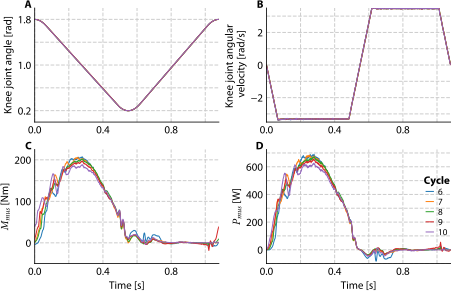

In [28]:
#| label: fig-r-te-timeseries
#| fig-cap: |
#|   Representative example of mechanical behaviour, shown for participant 5 under condition 0.35C. Time 
#|   series are only depicted for the active cycles, where time is set to zero at the start of knee extension 
#|   for each cycle. Individual cycles are represented by a different coloured lines. A) Measured knee joint 
#|   angle over time (note that these are indistinguishable between cycles). B) Measured knee joint angular 
#|   velocity over time (indistinguishable between cycles). C) ‘Muscular’ knee joint moment ($M_{mus}$) over 
#|   time, for cycles 6-10 (see Methods). $M_{mus}$ was calculated by subtracting average knee joint moment 
#|   during the passive cycles from the knee joint moment during the active cycles (see Methods). D) Instantaneous 
#|   ‘muscular’ mechanical power ($P_{mus}$) over time, for cycles 6-10 (see Methods). $P_{mus}$ was calculated as 
#|   the product of $M_{mus}$ and the measured knee joint angular velocity. Both $M_{mus}$ and $M_{Pus}$ were close 
#|   to zero during flexion, indicating that the net mechanical work was almost exclusively the result of mechanical 
#|   work during extension.

#%% Imports etc.
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
cwd = Path.cwd()
baseDir = cwd.parent
dataDir = baseDir / 'data'
funcDir = baseDir / 'analysis' / 'functions'
sys.path.append(str(funcDir))

# Custom imports
import cust_fig, helpers

plt.close('all')

# %% Load data
pp = 5
cond = '0.35C'
trial = 1

dataFldr = os.path.join(dataDir,'dataExp',f'pp{pp:02d}','AMPO measurements','')
filename = f'pp{pp:02d}_{cond}_t{trial:1d}'
df = pd.read_csv(dataFldr+filename+'.csv')
data = df.to_numpy()
time,phi,torque,torqueComp,_,_,emgQuad,emgHams,phase = data.T[0:9]

mTime = helpers.segments_to_array(time,phase)
mPhi = helpers.segments_to_array(phi,phase)
mTor = helpers.segments_to_array(torque,phase)
mTorComp = helpers.segments_to_array(torqueComp,phase)
mPhid = np.gradient(mPhi,0.001,axis=0)

# %% Figure setup
cust_fig.style(plt, fontname='MinionPro', fontsize=11, grid=True)

fig = plt.figure(figsize=(15.92/2.54+50/600, 10.5/2.54), constrained_layout=True)
gs = fig.add_gridspec(2, 2)
axs = np.array([[fig.add_subplot(gs[i, j]) for j in range(gs.ncols)] for i in range(gs.nrows)])
# axs[1,0].remove()
# axs[1,1].remove()
# axs[1,0] = fig.add_subplot(gs[1, :])
sel = [5,6,7,8,9]

# %% Panel A: Joint angle
ax = axs[0,0]
ax.plot(mTime[:,sel]-mTime[0,sel],mPhi[:,sel])
ax.set_ylabel("Knee joint angle [rad]")
ax.set_ylim(0,2)
ax.set_yticks([0.2, 1.0, 1.8])
ax.set_yticks([0.6, 1.4],minor=True)

# %% Panel B: Joint angular  velocity
ax = axs[0,1]
ax.plot(mTime[:,sel]-mTime[0,sel],mPhid[:,sel])
ax.set_ylabel('Knee joint angular \n velocity [rad/s]')
ax.set_ylim(-3.5,3.5)
ax.set_yticks([-2, 0, 2])
ax.set_yticks([-3, -1, 1, 3],minor=True)

# %% Panel C: Kinetics
ax = axs[1,0]
ax.plot(mTime[:,sel]-mTime[0,sel],mTorComp[:,sel])
ax.set_ylabel("$M_{mus}$ [Nm]")
ax.set_ylim(-50,225)
ax.set_yticks([0, 100, 200])
ax.set_yticks([50, 150],minor=True)

# %% Panel D: Power
ax = axs[1,1]
ax.plot(mTime[:,sel]-mTime[0,sel],-mTorComp[:,sel]*mPhid[:,sel])
ax.set_ylabel("$P_{mus}$ [W]")
ax.set_ylim(-100,725)
ax.set_yticks([0, 200, 400, 600])
ax.set_yticks([-100, 100, 300, 500, 700],minor=True)

# %% All panels
axs[1,0].set_xlabel('Time [s]')
axs[1,1].set_xlabel('Time [s]')

for ax in axs.flatten():
    ax.set_xlim(0,1.08)
    ax.set_xticks([0, 0.4, 0.8])
    ax.set_xticks([0.2, 0.6, 1.0],minor=True)

axs[1,1].legend(
    ["6","7","8","9","10"],
    title="Cycle",
    title_fontproperties={'weight': 'bold'},
    loc="center right", 
    bbox_to_anchor=(1.02, 0.5),
    handlelength=0.8,handletextpad=0.5,labelspacing=0.2
)

# %%
fig.canvas.draw()
cust_fig.add_labels(fig, axs.flatten(), ['A', 'B', 'C', 'D'])

# %% Show and save
plt.show()
# fig.savefig("r_te_timeseries.png", bbox_inches="tight", pad_inches=0, dpi=600)
fig.savefig("r_te_timeseries.pdf", bbox_inches="tight", pad_inches=0)
# fig.savefig("r_te_timeseries.svg", bbox_inches="tight", pad_inches=0)

# %% Checks
if len(sys.argv) > 1:
    check_size = sys.argv[1]
else:
    check_size = True  

if check_size == True or check_size == 'True':
    cust_fig.report_axes_size(fig,axs)
    # cust_fig.report_fig_size("r_te_timeseries.png") 
    cust_fig.report_fig_size("r_te_timeseries.pdf") 
    # cust_fig.report_fig_size("r_te_timeseries.svg") 



### Figure 8

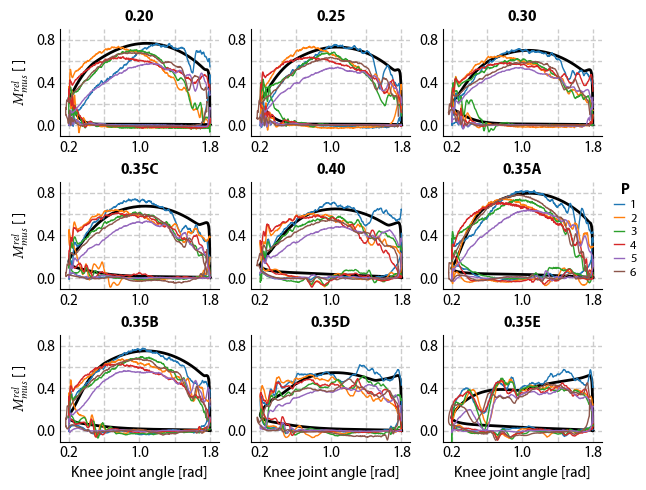

In [1]:
#| label: fig-r-kinetics
#| fig-cap: |
#|   Experimentally estimated and model-predicted relative ‘muscular’ knee joint moment ($M_{mus}^{rel}$) 
#|   for all conditions. $M_{mus}^{rel}$ was calculated by dividing the ‘muscular’ knee joint moment by 
#|   the maximal isometric knee joint moment of the individual participants (estimated from the isometric 
#|   knee joint moment-angle relationship; see @fig-r-te-isometric) or by that of the model. The thick 
#|   black line depicts the predicted $M_{mus}^{rel}$, while the thinner coloured lines depicts $M_{mus}^{rel}$ 
#|   for each individual participant (P). For each participant, $M_{mus}^{rel}$ is shown for the cycle with 
#|   highest measured AMPO.

#%% Imports etc.
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
cwd = Path.cwd()
baseDir = cwd.parent
dataDir = baseDir / 'data'
funcDir = baseDir / 'analysis' / 'functions'
sys.path.append(str(funcDir))

# Custom import
import cust_fig, helpers, kinetics

plt.close('all')

#%% Participant info
filepath = os.path.join(dataDir,'isometric-measurements.csv')
df = pd.read_csv(filepath, index_col=0)

pps = [1,2,3,4,5,6] # participant no.
n_pp = len(pps) # amount of participants
fmax = df['fmax [N]'].to_numpy() # [N] est maximal isometric CE force per particiapnt
trial = 1

# %% Figure setup
cust_fig.style(plt, fontname='MinionPro', fontsize=11, grid=True)

fig = plt.figure(figsize=(15.92/2.54+50/600, 12.15/2.54), constrained_layout=True)
gs = fig.add_gridspec(3, 3)
axs = np.array([[fig.add_subplot(gs[i, j]) for j in range(gs.ncols)] for i in range(gs.nrows)])

# %%
cond_names = ['0.20', '0.25', '0.30', '0.35C', '0.40', '0.35A', '0.35B', '0.35D', '0.35E']

for ax,cond_name in zip(axs.flatten(),cond_names):
    filepath = os.path.join(dataDir,'simsExp','cond_'+cond_name+'.csv')
    
    df = pd.read_csv(filepath)
    data = df.to_numpy().T
    time,phi,stim,fsee,gamma,lcerel,q,lmtc,fisomrel = data
    ax.plot(phi,fsee/5250,"k",linewidth=2, label='_nolegend_')  
    
    for iPP,pp in enumerate(pps):
        filepath = os.path.join(dataDir,'dataExp',f'pp{pp:02d}','AMPO measurements',f'pp{pp:02d}_{cond_name}_t{trial:1d}.csv')
         
        df = pd.read_csv(filepath)
        data = df.to_numpy()
        time,phi,_,torqueComp,_,_,emgQuad,emgHams,phase = data.T[0:9]
        
        mTime = helpers.segments_to_list(time,phase)
        mPhi = helpers.segments_to_list(phi,phase)
        mTorComp = helpers.segments_to_list(torqueComp,phase)
        
        # Calculate AMPO
        Wnet,Wpos,Wneg = kinetics.compute_work(phi,torqueComp,phase,'c')
        iMax = np.argmax(Wnet)
        fscale = fmax[iPP]*0.042
        
        ax.plot(mPhi[iMax],mTorComp[iMax]/fscale)
  
# %% 
axs[1,2].legend(
    ["1","2","3","4","5","6"],
    title="P",
    title_fontproperties={'weight': 'bold'},
    loc="center right", 
    bbox_to_anchor=(1.26, 0.55),
    handlelength=0.8,handletextpad=0.5,labelspacing=0.2
)
  
for iAx,ax in enumerate(axs.flatten()):
    ax.set_xlim(0.1,1.9)
    ax.set_ylim(-.1,0.9)
    ax.set_xticks([0.2, 1.0, 1.8])
    ax.set_xticks([0.6, 1.4],minor=True)
    ax.set_yticks([0,0.4,0.8]);
    ax.set_yticks([0.2,0.6],minor=True)
    ax.set_title(cond_names[iAx], fontweight='bold')
      
axs[2,0].set_xlabel("Knee joint angle [rad]")
axs[2,1].set_xlabel("Knee joint angle [rad]")
axs[2,2].set_xlabel("Knee joint angle [rad]")
axs[0,0].set_ylabel(r"$M_{mus}^{rel}$ [ ]")
axs[1,0].set_ylabel(r"$M_{mus}^{rel}$ [ ]")
axs[2,0].set_ylabel(r"$M_{mus}^{rel}$ [ ]")

# %% Show and save
plt.show()
# fig.savefig("r_kinetics.png", bbox_inches="tight", pad_inches=0, dpi=600)
fig.savefig("r_kinetics.pdf", bbox_inches="tight", pad_inches=0)
# fig.savefig("r_kinetics.svg", bbox_inches="tight", pad_inches=0)

# %% Checks
if len(sys.argv) > 1:
    check_size = sys.argv[1]
else:
    check_size = True  

if check_size == True or check_size == 'True':
    cust_fig.report_axes_size(fig,axs)
    # cust_fig.report_fig_size("r_kinetics.png") 
    cust_fig.report_fig_size("r_kinetics.pdf") 
    # cust_fig.report_fig_size("r_kinetics.svg") 



### Figure 9

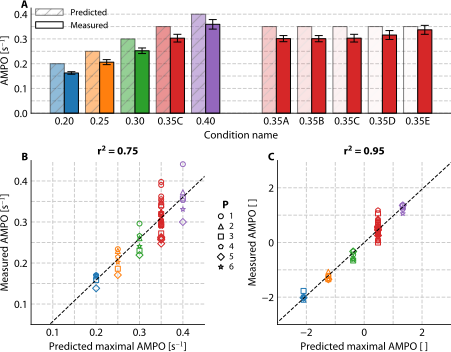

In [ ]:
#| label: fig-r-overview
#| fig-cap: |
#|   Measured AMPO versus predicted maximally attainable AMPO. A) Barplot showing predicted values with 
#|   diagonal hatching and semi-transparent fill ($\alpha$ = 0.5), and experimentally measured values fully 
#|   filled. Error bars denote the standard error of the mean. B) Scatterplot of measured versus predicted 
#|   maximally attainable AMPO normalised by $L_{CE}^{opt}$ and $F_{CE}^{max}$, with $F_{CE}^{max}$ estimated 
#|   individually for each participant. C) Scatterplot of measured versus predicted maximally attainable AMPO 
#|   normalised to z-scores. Participants (P) are distinguished by symbols.

#%% Imports etc.
import os
import sys
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
cwd = Path.cwd()
baseDir = cwd.parent
dataDir = baseDir / 'data'
funcDir = baseDir / 'analysis' / 'functions'
sys.path.append(str(funcDir))

# Custom imports
import cust_fig, kinetics, stats

plt.close('all')

# %% Info about conditions
# Load conditions
data = pd.read_csv(dataDir / 'conditions.csv', sep=',', header=None, dtype=str).to_numpy()

# Set conditions order
cond_names = ['0.20', '0.25', '0.30', '0.35C', '0.40', '0.35A', '0.35B', '0.35D', '0.35E']

# Previously I had a different order, so we need to re-order first
current_order = data[0, :]  # e.g., ['0.25', '0.20', '0.35C', ...]
# Find indices that would reorder to match condNames
reorder_idx = [np.where(current_order == c)[0][0] for c in cond_names]
# Reorder all columns
data = data[:, reorder_idx]

c_cf = data[1].astype(float)
c_fts = data[2].astype(float)
c_ampo = data[3].astype(float)

#%% Participant info
filepath = os.path.join(dataDir,'isometric-measurements.csv')
df = pd.read_csv(filepath, index_col=0)

pps = [1,2,3,4,5,6] # participant no.
n_pp = len(pps) # amount of participants
fmax = df['fmax [N]'].to_numpy() # [N] est maximal isometric CE force per particiapnt

#%% Figure setup
cust_fig.style(plt, fontname='MinionPro', fontsize=11, grid=True)

fig = plt.figure(figsize=(15.92/2.54 + 50/600, 12.64/2.54), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.56], wspace=0.05)
axs = np.array([[fig.add_subplot(gs[i, j]) for j in range(gs.ncols)] for i in range(gs.nrows)])
axs[0,0].remove();
axs[0,1].remove();
axs[0,0] = fig.add_subplot(gs[0, 0:2])

colorSet = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']
markers = ['o', '^', 's', 'p', 'D', '*']
markersize = 5

#%% Calculate predicted and measured AMPO
c_clrs = np.array([colorSet[0],colorSet[1],colorSet[2],colorSet[3],colorSet[4],colorSet[3],colorSet[3],colorSet[3],colorSet[3]])
c_num = ('1','2','3','4','5','6','7','8','9')

ampo_pred = np.array([0.2, 0.25, 0.3, 0.35, 0.4, 0.35, 0.35, 0.35, 0.35])
ampo_pred = np.repeat(ampo_pred[None, :], n_pp, axis=0)

day, trial = 4, 1
pps = [1, 2, 3, 4, 5, 6]
conds = np.array(['0.20', '0.25', '0.30', '0.35C', '0.40', '0.35A', '0.35B', '0.35D', '0.35E'])

ampo_exp = np.full((n_pp, 9), np.nan)

for iPP, pp in enumerate(pps):
    for iCond, cond in enumerate(conds):
        dataFldr = os.path.join(dataDir, 'dataExp', f'pp{pp:02d}', 'AMPO measurements', '')
        filename = f'pp{pp:02d}_{cond}_t{trial:1d}'
        df = pd.read_csv(os.path.join(dataFldr, filename + '.csv'))
        data = df.T.to_numpy()
        time, phi, _, torqueComp, _, _, emgQuad, emgHams, phase = data[0:9]

        iCycles = [5, 6, 7, 8, 9]
        if pp == 3 and cond == '0.35E':
            iCycles = [6, 7, 8, 9, 10]  # Adjust for shifted cycles

        Wnet, Wpos, Wneg = kinetics.compute_work(phi, torqueComp, phase, 'c', iCycles)
        ampo_exp[iPP, iCond] = np.max(Wnet * c_cf[iCond]) / (fmax[iPP] * 0.093)

#%% Stats
ampo_expmean = np.mean(ampo_exp, axis=0)
ampo_expsem = np.std(ampo_exp, axis=0, ddof=1) / np.sqrt(n_pp)

ampo_predZ = stats.zscore(ampo_pred)
ampo_expZ = stats.zscore(ampo_exp)

# Linear regressions
fitN = sp.stats.linregress(np.ravel(ampo_pred), np.ravel(ampo_exp))
fitZ = sp.stats.linregress(np.ravel(ampo_predZ), np.ravel(ampo_expZ))

#%% Panel A: Bar plot of predicted and measured normalised AMPO
ax = axs[0,0]

xpos = np.array([0,1,2,3,4, 6,7,8,9,10])
iSel = [0,1,2,3,4, 5,6,3,7,8]

ax.bar(xpos-0.2, ampo_pred[0,iSel], width=0.4,
       color=c_clrs[iSel], edgecolor="k", capsize=4, hatch='//', alpha=0.5, label='Predicted')
ax.bar(xpos+0.2, ampo_expmean[iSel], yerr=ampo_expsem[iSel], width = 0.4,
       color=c_clrs[iSel], edgecolor="k", capsize=4, label='Measured')
ax.grid(axis='x', visible=False)  # turn off x-axis gridlines
ax.set_xticks(xpos)
ax.set_xticklabels(conds[iSel])
ax.set_xlabel('Condition name')
ax.set_ylim(0,0.425)
ax.set_yticks([0.0, 0.1, 0.2, 0.3, 0.4])
ax.set_yticks([0.05, 0.15, 0.25, 0.35], minor=True)
ax.set_ylabel('AMPO ' + r'[$\mathregular{s}^{-1}$]')

# ax.set_ylabel('AMPO [s^-1^]')
leg = ax.legend(
    loc="upper left", 
    bbox_to_anchor=(0, 1.036),
    handleheight=0.7,
    handlelength=3
    )
# ax.spines['top'].set_visible(True)

# Force all legend boxes to white fill, keeping edge + hatch style
for lh in leg.legend_handles:
    lh.set_facecolor('white')
    lh.set_edgecolor('k')

#%% Panel B - Regression normalised AMPO
ax = axs[1,0]
x = np.array([-5, 5])

ax.plot(x, x * fitN.slope + fitN.intercept, color="k", linestyle="--")
n_rows, n_cols = ampo_pred.shape
for row_idx in range(n_rows):
    ax.scatter(
        ampo_pred[row_idx, :],           # all columns for this row
        ampo_exp[row_idx, :],
        marker=markers[row_idx],
        s=markersize**2,                 # scatter size is area, not diameter
        edgecolor=c_clrs,                # array of colors per column
        facecolor='none',
        linewidths=1
    )

ax.set_xlabel('Predicted maximal AMPO ' + r'[$\mathregular{s}^{-1}$]')
ax.set_ylabel('Measured AMPO ' + r'[$\mathregular{s}^{-1}$]')
# ax.set_title('$\mathregular{r^2}$ = 0.76', fontweight='bold')
ax.set_title(f'$\mathregular{{r^2}}$ = {fitN.rvalue**2:0.2f}',fontweight='bold')
ax.set_xlim(0.05, 0.45)
ax.set_ylim(0.05, 0.45)
ax.set_xticks([0.1, 0.2, 0.3, 0.4])
ax.set_xticks([0.15, 0.25, 0.35], minor=True)
ax.set_yticks([0.1, 0.2, 0.3, 0.4])
ax.set_yticks([0.15, 0.25, 0.35], minor=True)

#%% Panel C: Regression z-score AMPO
ax = axs[1,1]

ax.plot(x, x * fitZ.slope + fitZ.intercept, color='k', linestyle='--', label='_nolegend_')
n_rows, n_cols = ampo_pred.shape
for row_idx in range(n_rows):
    ax.scatter(
        ampo_predZ[row_idx, :],           # all columns for this row
        ampo_expZ[row_idx, :],
        marker=markers[row_idx],
        s=markersize**2,                 # scatter size is area, not diameter
        edgecolor=c_clrs,                # array of colors per column
        facecolor='none',
        linewidths=1
    )


ax.set_xlabel('Predicted maximal AMPO [ ]')
ax.set_ylabel('Measured AMPO [ ]')
ax.set_title(f'$\mathregular{{r^2}}$ = {fitZ.rvalue**2:0.2f}',fontweight='bold')
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-2, 0, 2])
ax.set_xticks([-1, 1], minor=True)
ax.set_yticks([-2, 0, 2])
ax.set_yticks([-1, 1], minor=True)

leg = ax.legend(
    ['1', '2', '3', '4', '5', '6'],
    title='P',
    title_fontproperties={'weight': 'bold'},
    loc='center',
    bbox_to_anchor=(0.5, 0.333),
    bbox_transform=fig.transFigure,
    handlelength=0.8,
    handletextpad=0.5,
    labelspacing=0.2,
)

# Force all legend boxes to white fill, keeping edge + hatch style
for lh in leg.legend_handles:
    lh.set_edgecolor('k')

#%%
cust_fig.add_labels(fig, axs.flatten(), ['A','','B','C'])

# We have problem that superscript of y-axis gets cropped. So lets do a fake text
from matplotlib.transforms import offset_copy
trans = offset_copy(fig.transFigure, fig, x=3, y=0, units='dots') # 3px to right
fig.text(0, 0.5, " ", transform=trans)

#%% Show and Save
plt.show()
# fig.savefig("r_overview.png", bbox_inches="tight", pad_inches=0, dpi=600)
fig.savefig("r_overview.pdf", bbox_inches="tight", pad_inches=0)
# fig.savefig("r_overview.svg", bbox_inches="tight", pad_inches=0)

#%% Checks
if len(sys.argv) > 1:
    check_size = sys.argv[1]
else:
    check_size = True  

if check_size == True or check_size == 'True':
    cust_fig.report_axes_size(fig,axs.flatten())
    # cust_fig.report_fig_size("r_overview.png") 
    cust_fig.report_fig_size("r_overview.pdf") 
    # cust_fig.report_fig_size("r_overview.svg") 


### Figure 10

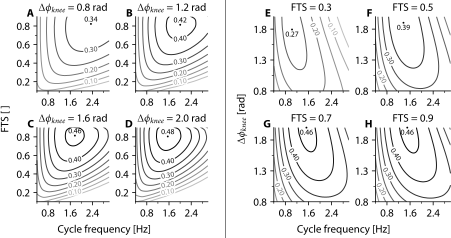

In [ ]:
#| label: fig-r-contour
#| fig-cap: |
#|   Predicted maximally attainable AMPO as a function of SSC parameters: cycle frequency, fraction of cycle 
#|   time spent shortening (FTS), and knee joint excursion ($\Delta \phi_{\text{knee}}$). For each subplot, 
#|   one SSC parameter was fixed, while the influence of the other two parameters on maximally attainable AMPO 
#|   (normalized to $L_{CE}^{opt}$ and $F_{CE}^{max}$) is depicted as contour lines. Dots indicate peak AMPO, 
#|   corresponding to the optimal combination of the two varying SSC parameters; values are shown at the top 
#|   left of each dot. A–D) Predicted maximally attainable AMPO as a function of cycle frequency and FTS for 
#|   four distinct knee joint excursions. E–H) Predicted maximally attainable AMPO as a function of cycle frequency 
#|   and knee joint excursion for four distinct FTS values.

# %% Imports etc.
import os, sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy import integrate, interpolate
from pathlib import Path

# Paths
cwd = Path.cwd()
baseDir = cwd.parent
dataDir = baseDir / 'data'
funcDir = baseDir / 'analysis' / 'functions'
sys.path.append(str(funcDir))

# Custom imports
import cust_fig

plt.close('all')

# %% Load Parameters
parFile = os.path.join(dataDir,'VAS_muspar.pkl')
muspar = pickle.load(open(parFile, 'rb'))

# %% Figure setup
cust_fig.style(plt, fontname='MinionPro', fontsize=11, grid=False)

fig = plt.figure(figsize=(15.92/2.54+50/600, 8.42/2.54), constrained_layout=True) # 3:1 ratio
subfigs = fig.subfigures(1, 2, wspace=0.1, width_ratios=[1,1.03])  # kleine ruimte zodat lijn mooi past
gs_left = subfigs[0].add_gridspec(2, 2)
axs_left = np.array([[fig.add_subplot(gs_left[i, j]) for j in range(gs_left.ncols)] for i in range(gs_left.nrows)])
gs_right = subfigs[1].add_gridspec(2, 2)
axs_right = np.array([[fig.add_subplot(gs_right[i, j]) for j in range(gs_right.ncols)] for i in range(gs_right.nrows)])

#%% Figure
kjeSet = [0.8, 1.2, 1.6, 2.0]
cfSet = np.arange(0.4,3.1,0.2)
ftsSet = np.arange(0.05,0.96,0.05)
for kje,ax in zip(kjeSet,axs_left.flatten()):
    AMPO = np.full((len(ftsSet),len(cfSet)),np.nan)
    for iCf,cf in enumerate(cfSet):
        for iFts,fts in enumerate(ftsSet):
            filepath = os.path.join(dataDir,'simsSSC',f'cf{cf:0.2f}Hz_fts{fts:0.2f}_kje{kje:0.2f}rad.csv')
            try:
                df = pd.read_csv(filepath)
                data = df.T.to_numpy()
                time,phi,stim,fsee,gamma,lcerel,q,lmtc,fisomrel = data
                AMPO[iFts,iCf] = -integrate.trapezoid(fsee*muspar['A1'],phi)*cf/(muspar['fmax']*muspar['lce_opt'])
            except:
                AMPO[iFts,iCf] = np.nan
    
    X, Y = np.meshgrid(cfSet,ftsSet)
    
    # Finer mesh
    data = AMPO

    x_flat = X.flatten()
    y_flat = Y.flatten()
    z_flat = data.flatten()

    # Remove NaN values for interpolation
    mask = ~np.isnan(z_flat)
    x_flat = x_flat[mask]
    y_flat = y_flat[mask]
    z_flat = z_flat[mask]

    # Define a finer grid for interpolation
    x_fine = np.linspace(cfSet[0],cfSet[-1],100); x_fine[-1] = cfSet[-1]
    y_fine = np.linspace(ftsSet[0],ftsSet[-1],100); y_fine[-1] = ftsSet[-1]
    x_fine, y_fine = np.meshgrid(x_fine, y_fine)

    # Perform the interpolation
    z_fine = interpolate.griddata((x_flat, y_flat), z_flat, (x_fine, y_fine), method='cubic')
    
    # Find maximum
    max_idx = np.nanargmax(z_fine)
    iRow, iCol = np.unravel_index(max_idx, z_fine.shape)
    
    optCF   = x_fine[iRow, iCol]
    optFTS  = y_fine[iRow, iCol]
    maxAMPO = z_fine[iRow, iCol]
    # print(maxAMPO)
    
    ax.scatter(optCF,optFTS, marker='.', facecolors='k', edgecolors='none', s=15)
    ax.text(optCF,optFTS+0.9*0.01, f'{maxAMPO:0.2f}', fontsize='x-small', va='bottom', ha='center')

    # z_fine[z_fine<0] = 0
    
    cmap = plt.get_cmap('gray_r')
    cmap = cust_fig.truncate_colormap(cmap, 0.25, 1)
    CS2 = ax.contour(x_fine,y_fine,z_fine,[0.05,0.10,0.15,0.2,0.25,0.30,0.35,0.40,0.45],cmap=cmap)
    
    contour_levels  = np.arange(0.1,np.floor(np.max(AMPO*10))/10+0.01,0.1)

    xvalue_label = np.repeat(optCF,len(contour_levels))
    yvalues_label = interpolate.griddata((x_fine.flatten()[y_fine.flatten()<optFTS], z_fine.flatten()[y_fine.flatten()<optFTS]), y_fine.flatten()[y_fine.flatten()<optFTS], (xvalue_label, contour_levels), method='cubic') 
    manual_locations = np.column_stack((xvalue_label,yvalues_label))
    labels = ax.clabel(CS2, fmt = '%0.2f',manual=manual_locations,fontsize='x-small')
    for txt in labels:
        txt.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])
    
# %% Panel A-D
for iAx,ax in enumerate(axs_left.flatten()):
    ax.set_xlim(0.4, 3)
    ax.set_xticks([0.8, 1.6, 2.4])
    ax.set_xticks([0.4, 1.2, 2.0, 2.8], minor=True)
    ax.set_ylim(0.1, 0.9)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8])
    ax.set_yticks([0.3, 0.5, 0.7], minor=True)
    ax.set_title(r'$\Delta \phi_{knee}$' + f' = {kjeSet[iAx]:0.1f} rad')

#%% Figure
ftsSet = [0.30, 0.50, 0.70, 0.90]
# ftsSet = [0.3, 0]

cfSet = np.arange(0.4,3.1,0.2)
kjeSet = np.arange(0.8,2.05,0.1)
for fts,ax in zip(ftsSet,axs_right.flatten()):   
    AMPO = np.full((len(kjeSet),len(cfSet)),np.nan)
    for iCf,cf in enumerate(cfSet):
        for iKje,kje in enumerate(kjeSet):
            filepath = os.path.join(dataDir,'simsSSC',f'cf{cf:0.2f}Hz_fts{fts:0.2f}_kje{kje:0.2f}rad.csv')
            try:
                df = pd.read_csv(filepath)
                data = df.T.to_numpy()
                time,phi,stim,fsee,gamma,lcerel,q,lmtc,fisomrel = data
                AMPO[iKje,iCf] = -integrate.trapezoid(fsee*muspar['A1'],phi)*cf/(muspar['fmax']*muspar['lce_opt'])
            except:
                AMPO[iKje,iCf] = np.nan
    X, Y = np.meshgrid(cfSet,kjeSet)
    
    # Finer mesh
    data = AMPO

    x_flat = X.flatten()
    y_flat = Y.flatten()
    z_flat = data.flatten()

    # Remove NaN values for interpolation
    mask = ~np.isnan(z_flat)
    x_flat = x_flat[mask]
    y_flat = y_flat[mask]
    z_flat = z_flat[mask]

    # Define a finer grid for interpolation
    x_fine = np.linspace(cfSet[0],cfSet[-1],100); x_fine[-1] = cfSet[-1]
    y_fine = np.linspace(kjeSet[0],kjeSet[-1],100); y_fine[-1] = kjeSet[-1]
    x_fine, y_fine = np.meshgrid(x_fine, y_fine)

    # Perform the interpolation
    z_fine = interpolate.griddata((x_flat, y_flat), z_flat, (x_fine, y_fine), method='cubic')
    
    # Find maximum
    max_idx = np.nanargmax(z_fine)
    iRow, iCol = np.unravel_index(max_idx, z_fine.shape)
    
    optCF   = x_fine[iRow, iCol]
    optKJE  = y_fine[iRow, iCol]
    maxAMPO = z_fine[iRow, iCol]
    # print(maxAMPO)
    
    ax.scatter(optCF,optKJE, marker='.', facecolors='k', edgecolors='none', s=15, clip_on=False)
    ax.text(optCF,optKJE-0.9*0.03, f'{maxAMPO:0.2f}', fontsize='x-small', va='top', ha='center')

    # z_fine[z_fine<0] = 0
    
    cmap = plt.get_cmap('gray_r')
    cmap = cust_fig.truncate_colormap(cmap, 0.25, 1)
    CS2 = ax.contour(x_fine,y_fine,z_fine,[0.05,0.10,0.15,0.2,0.25,0.30,0.35,0.40,0.45],cmap=cmap)
    
    contour_levels  = np.arange(np.min(np.ceil(AMPO*10)/10),np.floor(np.max(AMPO*10))/10+0.01,0.1)
    
    if np.isclose(fts, 0.3):
        manual_locations = np.array([[2.42472059, 1.79393939], 
                                     [1.81374019, 1.79393939]])
    elif np.isclose(fts, 0.5):
        manual_locations = np.array([[0.86370, 1.32637], # 0.3
                                     [0.61044, 1.02866]]) # 0.2
    elif np.isclose(fts, 0.7):
        manual_locations = np.array([[1.10274, 1.56574], # 0.4
                                     [0.82039, 1.24671], # 0.3
                                     [0.58786, 0.99962]]) # 0.2
    elif np.isclose(fts, 0.9):
        manual_locations = np.array([[1.10274, 1.56574], # 0.4
                                     [0.82039, 1.24671], # 0.3
                                     [0.58786, 0.99962]]) # 0.2
    else:
        manual_locations = None
    
    if manual_locations is None:
        labels = ax.clabel(CS2, fmt = '%0.2f',fontsize='x-small')
    else:
        labels = ax.clabel(CS2, fmt = '%0.2f',manual=manual_locations,fontsize='x-small')
    
# %% Add verticale lijn between blocks
line_ax = fig.add_axes([0.5, 0, 0.05, 1])  # [left, bottom, width, height] figcoördinates
line_ax.axvline(0, color='black', linewidth=1)  # line in the middle
line_ax.set_xticks([])
line_ax.set_yticks([])
line_ax.patch.set_alpha(0)  # maak de achtergrond transparant
line_ax.spines['top'].set_visible(False)
line_ax.spines['bottom'].set_visible(False)
line_ax.spines['left'].set_visible(False)
line_ax.spines['right'].set_visible(False)
    
# %% Panel E-H
for iAx,ax in enumerate(axs_right.flatten()):
    ax.set_xlim(0.4, 3)
    ax.set_xticks([0.8, 1.6, 2.4])
    ax.set_xticks([0.4, 1.2, 2.0, 2.8], minor=True)
    ax.set_ylim(0.8, 2.0)
    ax.set_yticks([0.8, 1.3, 1.8])
    ax.set_yticks([1.05, 1.55], minor=True)
    ax.set_title(f'FTS = {ftsSet[iAx]:0.2}')

# %%
subfigs[0].supxlabel('Cycle frequency [Hz]', fontsize='medium')
subfigs[0].supylabel('FTS [ ]', fontsize='medium')
subfigs[1].supxlabel('Cycle frequency [Hz]', fontsize='medium')
subfigs[1].supylabel(r'$\Delta \phi_{knee}$' + ' [rad]', fontsize='medium')

cust_fig.add_labels(fig, axs_left.flatten(), ['A', 'B', 'C', 'D'])
cust_fig.add_labels(fig, axs_right.flatten(), ['E', 'F', 'G', 'H'])

# %% Show and save 
plt.show()
# fig.savefig("r_contours2.png", bbox_inches="tight", pad_inches=0, dpi=600)
fig.savefig("r_contours2.pdf", bbox_inches="tight", pad_inches=0)
# fig.savefig("r_contours2.svg", bbox_inches="tight", pad_inches=0)

# %% Checks
if len(sys.argv) > 1:
    check_size = sys.argv[1]
else:
    check_size = True  

if check_size == True or check_size == 'True':
    cust_fig.report_axes_size(fig,np.concatenate([axs_left.flatten(), axs_right.flatten()]))
    # cust_fig.report_fig_size("r_contours2.png") 
    cust_fig.report_fig_size("r_contours2.pdf") 
    # cust_fig.report_fig_size("r_contours2.svg") 

## Appendix

### Figure A1

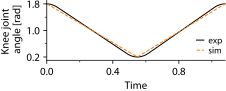

In [ ]:
#| label: appfig-dino-vs-cv
#| fig-cap: |
#|   Comparison between knee joint movements during the experiment and simulations. In the experiment, 
#|   knee joint movements were limited to an angular acceleration of 50 rad/s^2^. In contrast, in the simulations, 
#|   knee joint movements were used with different constant angular velocities for flexion and extension in order 
#|   to simulate a broad range knee joint movements.

#%% Imports etc.
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
cwd = Path.cwd()
baseDir = cwd.parent
dataDir = baseDir / 'data'
funcDir = baseDir / 'analysis' / 'functions'
sys.path.append(str(funcDir))

# Custom import
import cust_fig, trajectories

plt.close('all')

# %% Figure setup
cust_fig.style(plt, fontname='MinionPro', fontsize=11, grid=False)

fig = plt.figure(figsize=(15.92/2/2.54+54/600, 3.45/2.54), constrained_layout=True)
gs = fig.add_gridspec(1, 1)
axs = np.array([[fig.add_subplot(gs[i, j]) for j in range(gs.ncols)] for i in range(gs.nrows)])

# %% Find average extension and flexion times
# First calculate what it should be
data = pd.read_csv(dataDir / 'Conditions.csv', sep=',', header=None).to_numpy()
condNames = ['0.40', '0.35C', '0.30', '0.25', '0.20', '0.35A', '0.35B', '0.35D', '0.35E']
cfSet = data[1].astype(float)
ftsSet = data[2].astype(float)

fontname = 'MinionPro' if cust_fig.latex_has_package("MinionPro") and cust_fig.latex_has_package("MyriadPro") else 'libertinus'
cust_fig.style(plt, fontname=fontname, fontsize=11, grid=False)

colorSet = plt.rcParams['axes.prop_cycle'].by_key()['color']
colorSet[0] = colorSet[1]
colorSet[1] = '#000000'

#%% then check data to compare
iCond = 1
cf = cfSet[iCond]
fts = ftsSet[iCond]

time = np.linspace(0,1/cf,1000)

phi_dino = trajectories.dino(time,cf,fts,kje=1.6,phi_avg=1.0,acc=50,first_contr='E')[0]
phi_cv = trajectories.cv(time,cf,fts,kje=1.6,phi_avg=1.0)[0]

# %%
ax = axs[0,0]
ax.plot(time,phi_dino,color=colorSet[1])
ax.plot(time,phi_cv,linestyle='--', color=colorSet[0])
ax.set_xlabel('Time')
ax.set_ylabel('Knee joint \n angle [rad]')
ax.set_xlim(0,1/cf)
ax.set_xticks([0,0.2,0.4,0.6,0.8,1.0])
ax.set_xticks([0, 0.4, 0.8])
ax.set_xticks([0.2, 0.6, 1.0], minor=True)
ax.set_yticks([0.1,0.3,0.5,0.7,0.9], minor=True)

ax.set_ylim(0.1,1.9)
ax.set_yticks([0.2,1.0,1.8])
ax.set_yticks([0.6,1.4], minor=True)

ax.legend(['exp','sim'],loc="lower right", bbox_to_anchor=(1.01, 0.01),
                handlelength=0.8,handletextpad=0.5,labelspacing=0.2)

# %% Show and save
plt.show()
# fig.savefig("s_dino_vs_cv.png", bbox_inches="tight", pad_inches=0, dpi=600)
fig.savefig("s_dino_vs_cv.pdf", bbox_inches="tight", pad_inches=0)
# fig.savefig("s_dino_vs_cv.svg", bbox_inches="tight", pad_inches=0)

# %% Checks
if len(sys.argv) > 1:
    check_size = sys.argv[1]
else:
    check_size = True  

if check_size == True or check_size == 'True':
    cust_fig.report_axes_size(fig,axs)
    # cust_fig.report_fig_size("s_dino_vs_cv.png") 
    cust_fig.report_fig_size("s_dino_vs_cv.pdf") 
    # cust_fig.report_fig_size("s_dino_vs_cv.svg") 